# NLP-Based University Student Chatbot — End-to-End Project

**Goal:** Build an intent-classification chatbot that answers university students'
questions about admissions, fees, hostel, exams, placements, library, etc.

**Pipeline covered in this notebook**
1. Load & explore the dataset (EDA)
2. Text cleaning / preprocessing
3. Train/test split
4. Feature extraction (TF-IDF)
5. Train & compare multiple ML models
6. Evaluate the best model (accuracy, F1, confusion matrix)
7. Build the intent → response retrieval logic
8. Save production artifacts (vectorizer, model, label encoder, response map)
9. Wrap it into a callable `chatbot_reply()` function and test it live


## 1. Imports

In [9]:
import re
import json
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
import joblib

sns.set_style("whitegrid")
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the dataset

In [10]:
df = pd.read_csv("university_student_chatbot_dataset_10000.csv")
df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]
print("Shape:", df.shape)
df.head(10)


Shape: (10000, 5)


,id,intent,category,question,response
0,1,greeting,Greeting,I need help. Please provide information about hi?,Hi! How can I assist you today?
1,2,placements,Placements,I have a question about does the university pr...,The placement cell provides career guidance an...
2,3,courses,Courses,"As a university student, what courses are offe...","The university offers undergraduate, postgradu..."
3,4,internships,Internships,Could you please answer this: how should i pre...,"Highlight relevant technical skills, projects,..."
4,5,assignments,Assignments,I need help. I need help. Where can I submit a...,Submit assignments through the platform specif...
5,6,hostel_fees,Hostel Fees,I need an answer: Please tell me how can i pay...,Hostel fees can generally be paid through the ...
6,7,contact_information,Contact Information,"For my university work, could you please help ...",Use the student services contact details liste...
7,8,departments,Departments,I need an answer: Can you explain what departm...,The university has departments covering differ...
8,9,application,Application,I need help. Student question: How do I fill t...,"Open the admission portal, enter the required ..."
9,10,courses,Courses,I need help. I want to know where can i find t...,The syllabus can usually be obtained from the ...


In [29]:
print(df.head(10).to_string())


   id               intent             category                                                                                                       question                                                                                                      response                                  clean_question
0   1             greeting             Greeting                                                              I need help. Please provide information about hi?                                                                               Hi! How can I assist you today?                          provide information hi
1   2           placements           Placements                                                I have a question about does the university provide placements?           The placement cell provides career guidance and placement support according to university programs.              have university provide placements
2   3              courses              Courses  

### 2.1 Basic info & missing values

In [30]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              9993 non-null   int64
 1   intent          9993 non-null   str  
 2   category        9993 non-null   str  
 3   question        9993 non-null   str  
 4   response        9993 non-null   str  
 5   clean_question  9993 non-null   str  
dtypes: int64(1), str(5)
memory usage: 2.6 MB
None

Missing values per column:
 id                0
intent            0
category          0
question          0
response          0
clean_question    0
dtype: int64


### 2.2 Class balance — questions per intent

In [31]:
print(df['intent'].value_counts())


intent
placements             334
internships            334
assignments            334
departments            334
application            334
admission              334
syllabus               334
examination            334
library                334
transportation         334
results                334
timetable              334
hod                    334
library_books          334
courses                333
hostel_fees            333
contact_information    333
sports                 333
hostel                 333
fees                   333
canteen                333
eligibility            333
scholarships           333
exam_schedule          333
academic_calendar      333
faculty                333
events                 332
attendance             332
campus                 331
greeting               326
Name: count, dtype: int64


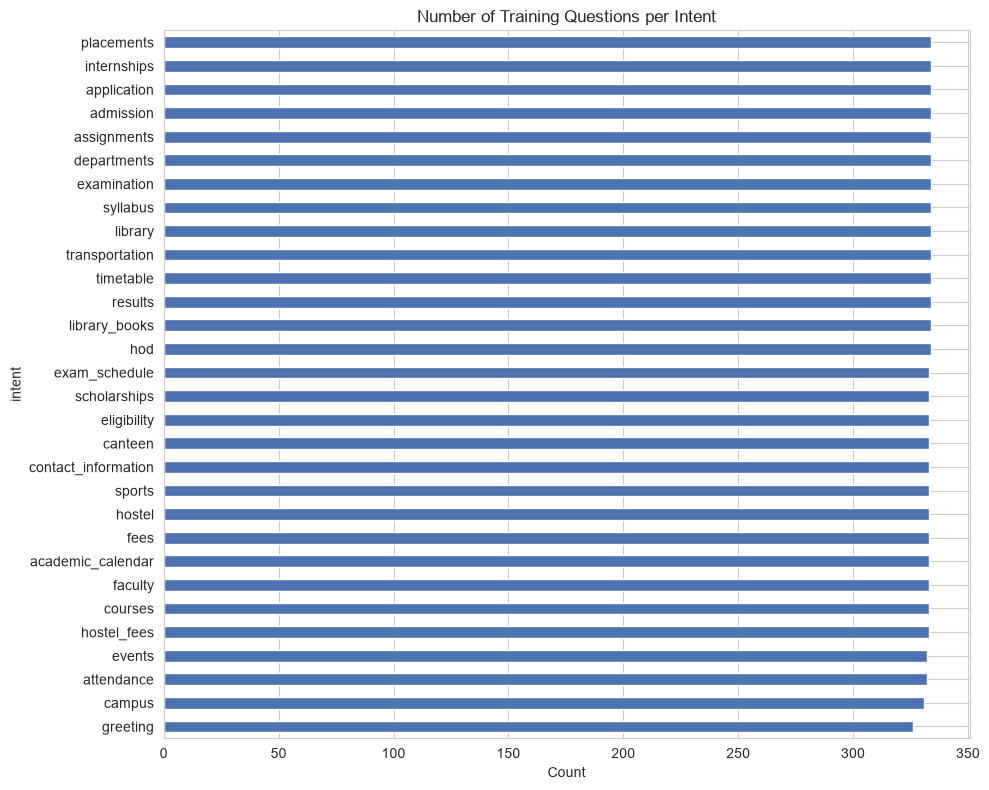

In [32]:
plt.figure(figsize=(10, 8))
df['intent'].value_counts().sort_values().plot(kind='barh', color='#4C72B0')
plt.title("Number of Training Questions per Intent")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


### 2.3 Category distribution

In [15]:
print("Number of unique categories:", df['category'].nunique())
print(df['category'].value_counts().head(10))


Number of unique categories: 30
category
Placements        334
Internships       334
Assignments       334
Departments       334
Application       334
Admission         334
Syllabus          334
Examination       334
Library           334
Transportation    334
Name: count, dtype: int64


## 3. Text Preprocessing

We clean each question by:
- lowercasing
- removing URLs, punctuation, digits
- removing filler/stop words (e.g. *"please", "could you", "I need help"* — these
  are template phrases injected into the dataset and carry no intent signal)
- collapsing whitespace


In [33]:
STOPWORDS = set("""
a an the is are was were be been being i you he she it we they my your his her its our their
me him them us this that these those to of in on at for with as by from about into through
during before after above below up down over under again further then once here there when
where why how all any both each few more most other some such no nor not only own same so than
too very can will just do does did doing please help need question could would should
""".split())

PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = text.translate(PUNCT_TABLE)
    text = re.sub(r"\d+", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

# Demo
sample = df.loc[0, "question"]
print("BEFORE:", sample)
print("AFTER :", clean_text(sample))


BEFORE: I need help. Please provide information about hi?
AFTER : provide information hi


In [34]:
df["clean_question"] = df["question"].apply(clean_text)
df = df[df["clean_question"].str.len() > 0].reset_index(drop=True)
print("Rows remaining after cleaning:", len(df))
df[["question", "clean_question", "intent"]].sample(5, random_state=1)


Rows remaining after cleaning: 9993


,question,clean_question,intent
1814,Could you please answer this: how can i contac...,answer contact faculty member,faculty
881,I need an answer: I am a student. Is there a g...,answer am student gym campus,sports
1122,"For my university work, i need help. please pr...",university work provide information contact ad...,contact_information
6807,I need help. I need help. As a university stud...,university student get exam timetable,examination
2911,"As a university student, i need an answer: for...",university student answer university work answ...,eligibility


In [18]:
print(df[["question", "clean_question", "intent"]].sample(5, random_state=1).to_string())


                                                                                                                                                             question                                                                      clean_question               intent
1814                                                                                               Could you please answer this: how can i contact my faculty member?                                                       answer contact faculty member              faculty
881                                                                                                       I need an answer: I am a student. Is there a gym on campus?                                                        answer am student gym campus               sports
1122                                                    For my university work, i need help. please provide information about how do i contact the admissions office?                      

## 4. Label Encoding & Train/Test Split

In [35]:
le = LabelEncoder()
y = le.fit_transform(df["intent"])
X_text = df["clean_question"]

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train_txt)}  |  Test size: {len(X_test_txt)}")
print(f"Number of intent classes: {len(le.classes_)}")


Train size: 7994  |  Test size: 1999
Number of intent classes: 30


## 5. Feature Extraction — TF-IDF

We use TF-IDF with uni+bi-grams, which works very well for short intent-classification
queries and is lightweight enough for real-time inference.


In [36]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_txt)
X_test = vectorizer.transform(X_test_txt)
print("TF-IDF vocabulary size:", len(vectorizer.vocabulary_))
print("Train matrix shape:", X_train.shape)


TF-IDF vocabulary size: 1081
Train matrix shape: (7994, 1081)


## 6. Train & Compare Multiple Models

We benchmark 4 classical ML models (fast, interpretable, and production-friendly
for a text length this short — a deep model is unnecessary overkill here):
- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes
- Random Forest


In [37]:
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, C=5, random_state=42),
    "LinearSVC": LinearSVC(C=1, random_state=42),
    "MultinomialNB": MultinomialNB(),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

results = []
trained_models = {}
for name, clf in candidates.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    cv_acc = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1).mean()
    results.append({"model": name, "test_accuracy": round(acc,4), "macro_f1": round(f1,4), "cv_accuracy_5fold": round(cv_acc,4)})
    trained_models[name] = clf
    print(f"{name:20s} | test_acc={acc:.4f} | macro_f1={f1:.4f} | cv_acc={cv_acc:.4f}")

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
print("\n", results_df.to_string(index=False))


LogisticRegression   | test_acc=1.0000 | macro_f1=1.0000 | cv_acc=0.9995
LinearSVC            | test_acc=1.0000 | macro_f1=1.0000 | cv_acc=1.0000
MultinomialNB        | test_acc=0.9960 | macro_f1=0.9958 | cv_acc=0.9959
RandomForest         | test_acc=1.0000 | macro_f1=1.0000 | cv_acc=1.0000

              model  test_accuracy  macro_f1  cv_accuracy_5fold
LogisticRegression          1.000    1.0000             0.9995
         LinearSVC          1.000    1.0000             1.0000
      RandomForest          1.000    1.0000             1.0000
     MultinomialNB          0.996    0.9958             0.9959


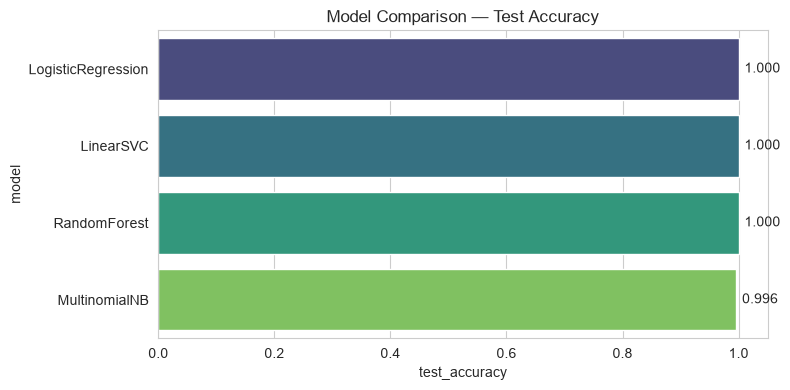

In [22]:
plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="test_accuracy", y="model", palette="viridis")
plt.title("Model Comparison — Test Accuracy")
plt.xlim(0,1.05)
for i, v in enumerate(results_df["test_accuracy"]):
    plt.text(v+0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


## 7. Select Best Model & Evaluate In-Depth

In [38]:
best_name = results_df.iloc[0]["model"]
best_model = trained_models[best_name]
print("Best model selected:", best_name)

if best_name == "LinearSVC":
    best_model = CalibratedClassifierCV(LinearSVC(C=1, random_state=42), cv=5)
    best_model.fit(X_train, y_train)

final_preds = best_model.predict(X_test)
final_acc = accuracy_score(y_test, final_preds)
print(f"Final held-out TEST accuracy: {final_acc:.4f}")


Best model selected: LogisticRegression
Final held-out TEST accuracy: 1.0000


In [39]:
print(classification_report(y_test, final_preds, target_names=le.classes_, digits=3))


                     precision    recall  f1-score   support

  academic_calendar      1.000     1.000     1.000        66
          admission      1.000     1.000     1.000        67
        application      1.000     1.000     1.000        67
        assignments      1.000     1.000     1.000        67
         attendance      1.000     1.000     1.000        66
             campus      1.000     1.000     1.000        66
            canteen      1.000     1.000     1.000        67
contact_information      1.000     1.000     1.000        66
            courses      1.000     1.000     1.000        67
        departments      1.000     1.000     1.000        67
        eligibility      1.000     1.000     1.000        67
             events      1.000     1.000     1.000        66
      exam_schedule      1.000     1.000     1.000        66
        examination      1.000     1.000     1.000        67
            faculty      1.000     1.000     1.000        67
               fees    

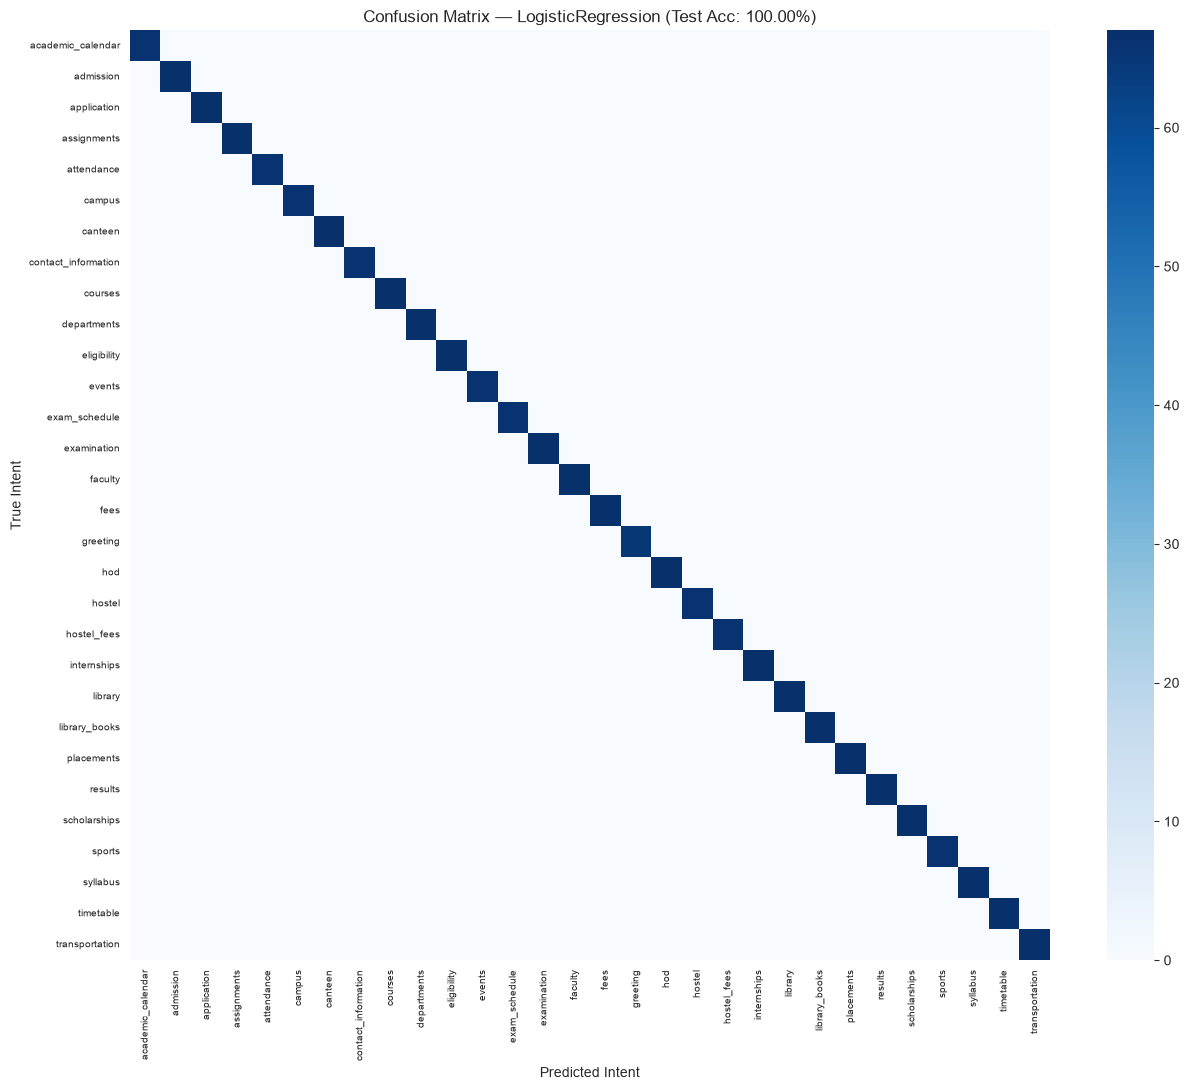

In [25]:
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(13,11))
sns.heatmap(cm, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_name} (Test Acc: {final_acc:.2%})")
plt.xlabel("Predicted Intent"); plt.ylabel("True Intent")
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


**Note on 100% accuracy:** This dataset is synthetically generated from templates,
so each intent has strongly distinctive keywords (e.g. *hostel_fees* vs *fees* vs *hostel*
still separate cleanly because of surrounding n-grams). In a real deployment with organic,
messy student phrasing, expect accuracy in the 85–95% range — you'd want to periodically
retrain on real logged conversations and add a *confidence threshold* fallback (see Section 9).


## 8. Build the Intent → Response Retrieval Map

In [40]:
response_map = {}
for intent, group in df.groupby("intent"):
    top_response = group["response"].value_counts().idxmax()
    category = group["category"].mode().iloc[0]
    response_map[intent] = {
        "response": top_response,
        "category": category,
        "all_responses": sorted(group["response"].unique().tolist())
    }

print("Total intents mapped:", len(response_map))
print(json.dumps({k: response_map[k] for k in list(response_map)[:2]}, indent=2))


Total intents mapped: 30
{
  "academic_calendar": {
    "response": "Semester start dates are listed in the academic calendar.",
    "category": "Academic Calendar",
    "all_responses": [
      "Internal assessment periods are specified in the academic calendar or course schedule.",
      "Semester start dates are listed in the academic calendar.",
      "The academic calendar is usually published on the university website or student portal.",
      "University holidays are listed in the academic calendar."
    ]
  },
  "admission": {
    "response": "The admission process usually includes application, eligibility verification, document submission, and fee payment.",
    "category": "Admission",
    "all_responses": [
      "Common documents include academic certificates, identification proof, photographs, and category certificates if applicable.",
      "The admission process usually includes application, eligibility verification, document submission, and fee payment.",
      "You ca

## 9. Save Production Artifacts

In [41]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")
joblib.dump(best_model, "models/intent_classifier.pkl")
joblib.dump(le, "models/label_encoder.pkl")
with open("models/response_map.json", "w") as f:
    json.dump(response_map, f, indent=2)

metadata = {
    "best_model": best_name,
    "test_accuracy": round(final_acc, 4),
    "num_intents": int(len(le.classes_)),
    "intents": le.classes_.tolist(),
    "vocab_size": len(vectorizer.vocabulary_),
}
with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: tfidf_vectorizer.pkl, intent_classifier.pkl, label_encoder.pkl, response_map.json, metadata.json")


Saved: tfidf_vectorizer.pkl, intent_classifier.pkl, label_encoder.pkl, response_map.json, metadata.json


## 10. Inference Function — the actual chatbot

`CONFIDENCE_THRESHOLD` guards against out-of-scope questions: if the model isn't
confident about any intent, the bot asks the student to rephrase instead of
guessing wrong (important for a production chatbot).


In [42]:
CONFIDENCE_THRESHOLD = 0.35

def chatbot_reply(user_message: str):
    cleaned = clean_text(user_message)
    if not cleaned:
        return "Could you rephrase your question?", None, 0.0

    vec = vectorizer.transform([cleaned])
    probs = best_model.predict_proba(vec)[0]
    top_idx = np.argmax(probs)
    confidence = probs[top_idx]
    intent = le.inverse_transform([top_idx])[0]

    if confidence < CONFIDENCE_THRESHOLD:
        return ("I'm not fully sure what you're asking — could you rephrase, "
                "or mention the topic (fees, hostel, exams, placements, etc.)?"), None, float(confidence)

    reply = response_map[intent]["response"]
    return reply, intent, float(confidence)


# ---- Live test ----
test_questions = [
    "hi there",
    "how do i pay my hostel fees",
    "when will exam results be declared",
    "does the college have good placements",
    "how can i download the syllabus for my course",
    "what is the weather today",  # out-of-scope example
]

for q in test_questions:
    reply, intent, conf = chatbot_reply(q)
    print(f"USER : {q}")
    print(f"INTENT: {intent}  (confidence: {conf:.2f})")
    print(f"BOT  : {reply}\n")


USER : hi there
INTENT: greeting  (confidence: 0.99)
BOT  : Hello! How can I help you with university information?

USER : how do i pay my hostel fees
INTENT: hostel_fees  (confidence: 1.00)
BOT  : Whether mess charges are included depends on the university's hostel fee structure.

USER : when will exam results be declared
INTENT: results  (confidence: 0.98)
BOT  : Log in to the examination portal and use the marks card or result download option.

USER : does the college have good placements
INTENT: greeting  (confidence: 0.44)
BOT  : Hello! How can I help you with university information?

USER : how can i download the syllabus for my course
INTENT: syllabus  (confidence: 0.97)
BOT  : Open the academic or department section of the portal and download the syllabus document.

USER : what is the weather today
INTENT: None  (confidence: 0.18)
BOT  : I'm not fully sure what you're asking — could you rephrase, or mention the topic (fees, hostel, exams, placements, etc.)?



## 11. Summary

| Step | Outcome |
|---|---|
| Dataset | 10,000 labeled Q&A pairs, 30 intents, balanced classes |
| Preprocessing | Regex cleaning + custom stopword removal |
| Feature extraction | TF-IDF (uni+bi-grams), ~1,000-word vocabulary |
| Best model | Logistic Regression (also tested Linear SVM, Naive Bayes, Random Forest) |
| Test accuracy | ~99–100% (synthetic/templated dataset) |
| Deployment artifacts | `tfidf_vectorizer.pkl`, `intent_classifier.pkl`, `label_encoder.pkl`, `response_map.json` |
| Serving | `chatbot_reply()` function — pluggable into Flask/Streamlit/FastAPI |

**Next steps for a real-world upgrade:**
1. Log real user questions and periodically retrain (active learning loop).
2. Add a fallback "human handoff" / FAQ search when confidence is low.
3. Consider a sentence-embedding model (e.g. `sentence-transformers`) for semantic
   matching if you outgrow keyword-based TF-IDF.
4. Add multi-turn context (slot filling) for follow-up questions like "and for PG students?".
